# 3. Model Analysis

This notebook analyzes model predictions and investigates individual creatures.

**Input:**
- `helper_files/engineered_features.parquet`
- `pickled_models/hp_model_cr*.pkl`

**Output:**
- `data/engineered_features.csv`
- `data/feature_contributions.csv`

## Imports and Configs

In [25]:
import numpy as np
import os
import pandas as pd
import sys

from pathlib import Path

In [26]:
# Detect execution context and set paths dynamically
sys.path.insert(0, '.')

# Get the current working directory
cwd = Path.cwd()

# Check if we're in the notebooks directory or project root
if cwd.name == 'notebooks':
    # Running from notebooks directory (in Jupyter)
    DATA_DIR = '../data'
    PICKLED_MODELS_DIR = '../pickled_models'
    MONSTER_BUILDER_DIR = '../monster-builder-v2'
    HELPERS_DIR = './helper_files'
    IO_DIR = './notebooks_io'
    IN_NB_DIR = False
else:
    # Running from project root (via run_three_tier_model.py)
    DATA_DIR = './data'
    PICKLED_MODELS_DIR = './pickled_models'
    MONSTER_BUILDER_DIR = './monster-builder-v2'
    HELPERS_DIR = './notebooks/helper_files'
    IO_DIR = './notebooks/notebooks_io'
    IN_NB_DIR = False

print(f"📁 Execution context detected:")
print(f"   Current directory: {cwd}")
print(f"   Data directory: {DATA_DIR}")
print(f"   Models directory: {PICKLED_MODELS_DIR}")

print("Imports successful")

📁 Execution context detected:
   Current directory: /workspaces/matrix_v0
   Data directory: ./data
   Models directory: ./pickled_models
Imports successful


In [27]:
# Add helper_files to path
if IN_NB_DIR is True:
    from helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS
    )

    print("Imports successful")
else:
    from notebooks.helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS
    )

    print("Imports successful")


Imports successful


## Load Data and Models

In [28]:
import_path = DATA_DIR + '/engineered_features.csv'
df = pd.read_csv(import_path)

In [29]:
import_path = DATA_DIR + '/feature_contributions.csv'
contributions_df = pd.read_csv(import_path)

In [30]:
phase3_features = get_phase3_features()

In [31]:
results = {}
load_path = PICKLED_MODELS_DIR + "/hp_model_tier.pkl"
# Save each model
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:

    filepath = load_path.replace('tier', tier)
    results[tier] = load_model(filepath)
    print(f"Loaded {tier} model to {filepath}")

print("\nAll models loaded successfully!")

Loaded cr1 model to ./pickled_models/hp_model_cr1.pkl
Loaded cr2 model to ./pickled_models/hp_model_cr2.pkl
Loaded cr3 model to ./pickled_models/hp_model_cr3.pkl
Loaded cr4 model to ./pickled_models/hp_model_cr4.pkl
Loaded cr5 model to ./pickled_models/hp_model_cr5.pkl

All models loaded successfully!


In [32]:
results['cr1'].keys()


dict_keys(['model', 'scaler', 'feature_names', 'train_count', 'test_r2', 'test_mae'])

## Model Analysis

In [33]:
summarize_model_performance(results)


5-BUCKET HP MODEL TRAINING COMPLETE

MODEL PERFORMANCE SUMMARY:

   CR < 1 Model:
      Training samples: 113
      Test R²:  0.4533
      Test MAE: 4.76 HP

   CR 1-4 Model:
      Training samples: 99
      Test R²:  0.5577
      Test MAE: 11.36 HP

   CR 5-10 Model:
      Training samples: 65
      Test R²:  0.4524
      Test MAE: 18.28 HP

   CR 11-16 Model:
      Training samples: 27
      Test R²:  0.9948
      Test MAE: 1.80 HP

   CR > 16 Model:
      Training samples: 20
      Test R²:  0.9559
      Test MAE: 15.68 HP

All 5 models trained successfully!


In [34]:
# Display top feature coefficients for each tier
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:
    print(f"\n{tier.upper()} Top Features by Coefficient:")
    coefs = results[tier]['model'].coef_
    coef_df = pd.DataFrame({
        'feature': phase3_features,
        'coefficient': coefs
    }).sort_values('coefficient', key=abs, ascending=False)
    
    print(coef_df.head(10).to_string(index=False))


CR1 Top Features by Coefficient:
                 feature  coefficient
  speed_ground_deviation     2.302075
condition_immunity_count     2.149940
     speed_fly_deviation     1.986209
      inflicts_petrified    -1.392350
      inflicts_paralyzed    -0.995524
     total_ability_count    -0.964471
  save_proficiency_count     0.778282
        has_spellcasting    -0.707716
             speed_climb    -0.680525
    darkvision_deviation     0.465657

CR2 Top Features by Coefficient:
                feature  coefficient
skill_proficiency_count    -4.730407
 save_proficiency_count     4.293876
            speed_climb    -3.546844
    vulnerability_count     3.309433
       inflicts_charmed    -3.054040
     inflicts_petrified    -2.787971
             speed_swim     2.715784
           speed_burrow    -2.681999
    inflicts_frightened    -2.386256
            trait_count     2.061126

CR3 Top Features by Coefficient:
                 feature  coefficient
  save_proficiency_count    11.8668

## Investigate Specific Creatures

In [56]:
# df[df['Name'].str.contains('Dragon')].head()

In [57]:
# Interactive investigation
# Uncomment and modify to investigate specific creatures:
# Oni, Unicorn way too penalized for different reasons.
investigate_creature('Oni', df, contributions_df)

  ONI (CR 7.0)

Actual HP:             110
Predicted HP:           45
Error:                 -65  ( -58.9%)

--------------------------------------------------------------------------------

PHASE 1: CR BASELINE
  HP Baseline (CR 7.0):                               156

PHASE 2: COMBAT STATS
  Feature: ac_deviation                   value:    1.0  hp impact:     -4
  Feature: attack_deviation               value:    0.0  hp impact:     -0
  Feature: dpr_deviation                  value:   97.0  hp impact:   -121
  Feature: save_dc_deviation              value:   -2.0  hp impact:     12
  Feature: has_flying                     value:    1.0  hp impact:     -5
  Feature: has_advantage_condition        value:    0.0  hp impact:     -0
  Feature: has_disadvantage_condition     value:    0.0  hp impact:      0
  Feature: has_attackers_advantage        value:    0.0  hp impact:      0
  Feature: inflicts_prone                 value:    0.0  hp impact:     -0
  ------------------------------

In [52]:
[c for c in contributions_df.columns if 'feature' in c]

[]

In [53]:
_df = analysis_dfs['cr3']
_df.sort_values('predicted_hp')

,Name,Type,Size,Challenge_Rating,cr_numeric,cr_tier,HP,hp_baseline,actual_hp,predicted_hp,...,inflicts_paralyzed,inflicts_petrified,inflicts_restrained,inflicts_stunned,Actual_HP,Predicted_HP,CR,Error,Abs_Error,Pct_Error
23,Unicorn,celestial,Large,5,5.0,cr3,67 (9d10+18),114.0,67,26.798148,...,0,0,1,0,67,26.798148,5.0,40.201852,40.201852,60.002765
29,Mage,humanoid (any race),Medium,6,6.0,cr3,40 (9d8),134.4,40,34.745440,...,0,0,0,0,40,34.745440,6.0,5.254560,5.254560,13.136401
38,Oni,giant,Large,7,7.0,cr3,110 (13d10+39),156.0,110,45.156698,...,0,0,0,0,110,45.156698,7.0,64.843302,64.843302,58.948457
8,Salamander,elemental,Large,5,5.0,cr3,90 (12d10+24),114.0,90,69.431730,...,0,0,1,0,90,69.431730,5.0,20.568270,20.568270,22.853633
49,Chain Devil,fiend (devil),Medium,8,8.0,cr3,85 (10d8+40),163.2,85,76.101610,...,0,0,1,0,85,76.101610,8.0,8.898390,8.898390,10.468694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,Young Gold Dragon,dragon,Large,10,10.0,cr3,178 (17d10+85),186.0,178,174.427952,...,0,0,0,0,178,174.427952,10.0,3.572048,3.572048,2.006768
64,Aboleth,aberration,Large,10,10.0,cr3,135 (18d10+36),186.0,135,175.201886,...,0,0,0,0,135,175.201886,10.0,-40.201886,40.201886,-29.779175
55,Treant,plant,Huge,9,9.0,cr3,138 (12d12+60),174.0,138,185.306887,...,0,0,0,0,138,185.306887,9.0,-47.306887,47.306887,-34.280353
60,Deva,celestial,Medium,10,10.0,cr3,136 (16d8+64),186.0,136,192.147553,...,0,0,0,0,136,192.147553,10.0,-56.147553,56.147553,-41.284965


In [40]:
# List worst predictions
# print("\nWorst Over-predictions (predicted > actual):")
# over_pred = df[df['hp_delta'] > 0].nlargest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(over_pred.to_string(index=False))

# print("\nWorst Under-predictions (predicted < actual):")
# under_pred = df[df['hp_delta'] < 0].nsmallest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(under_pred.to_string(index=False))

# print("\nBest Predictions:")
# df_check_best = df[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']].copy()
# df_check_best['hp_delta_pct_abs'] = df_check_best['hp_delta_pct'].abs()
# best = df_check_best.nsmallest(10, 'hp_delta_pct_abs')
# print(best.to_string(index=False))

# Deatiled Model Breakdown

In [41]:
analysis_dfs = analyze_predictions_by_cr(df)



CR < 1 - Best 10 Predictions:
        Name    CR  Actual_HP  Predicted_HP     Error
     Cultist 0.125          9      9.000007 -0.000007
  Cockatrice 0.500         27     26.999993  0.000007
       Camel 0.125         15     14.989158  0.010842
        Pony 0.125         11     10.927500  0.072500
    Scorpion 0.000          1      0.825552  0.174448
       Raven 0.000          1      0.721101  0.278899
Flying Sword 0.250         17     16.687710  0.312290
      Zombie 0.250         22     22.312404 -0.312404
        Worg 0.500         26     25.528170  0.471830
        Wolf 0.250         11     10.505523  0.494477

CR < 1 - Worst 10 Predictions:
                 Name   CR  Actual_HP  Predicted_HP      Error
                  Orc 0.50         15     26.010617 -11.010617
Giant Poisonous Snake 0.25         11     -0.063841  11.063841
    Constrictor Snake 0.25         13      1.524255  11.475745
           Black Bear 0.50         19     30.513171 -11.513171
               Dretch 0.25  

In [42]:
# analysis_dfs['cr2']['actual_hp'].value_counts()

In [43]:
_df_check = analysis_dfs['cr2']
_df_check[_df_check['actual_hp'] == 45]


,Name,Type,Size,Challenge_Rating,cr_numeric,cr_tier,HP,hp_baseline,actual_hp,predicted_hp,...,inflicts_paralyzed,inflicts_petrified,inflicts_restrained,inflicts_stunned,Actual_HP,Predicted_HP,CR,Error,Abs_Error,Pct_Error
87,Ghost,undead,Medium,4,4.0,cr2,45 (10d8),100.8,45,45.579061,...,0,0,0,0,45,45.579061,4.0,-0.579061,0.579061,-1.286802
57,Rhinoceros,beast,Large,2,2.0,cr2,45 (6d10+12),54.0,45,47.875860,...,0,0,0,0,45,47.875860,2.0,-2.875860,2.875860,-6.390800
13,Giant Hyena,beast,Large,1,1.0,cr2,45 (6d10+12),49.5,45,48.229013,...,0,0,0,0,45,48.229013,1.0,-3.229013,3.229013,-7.175584
50,Hunter Shark,beast,Large,2,2.0,cr2,45 (6d10+12),54.0,45,49.045978,...,0,0,0,0,45,49.045978,2.0,-4.045978,4.045978,-8.991061
52,Merrow,monstrosity,Large,2,2.0,cr2,45 (6d10+12),54.0,45,53.636179,...,0,0,0,0,45,53.636179,2.0,-8.636179,8.636179,-19.191508
74,Wight,undead,Medium,3,3.0,cr2,45 (6d8+18),78.0,45,35.832055,...,0,0,0,0,45,35.832055,3.0,9.167945,9.167945,20.373212
47,Ochre Jelly,ooze,Large,2,2.0,cr2,45 (6d10+12),54.0,45,35.800799,...,0,0,0,0,45,35.800799,2.0,9.199201,9.199201,20.442669
66,Hell Hound,fiend,Medium,3,3.0,cr2,45 (7d8+14),78.0,45,56.581022,...,0,0,0,0,45,56.581022,3.0,-11.581022,11.581022,-25.735605
39,Silver Dragon Wyrmling,dragon,Medium,2,2.0,cr2,45 (6d8+18),54.0,45,29.665527,...,1,0,0,0,45,29.665527,2.0,15.334473,15.334473,34.076607
41,Centaur,monstrosity,Large,2,2.0,cr2,45 (6d10+12),54.0,45,27.190514,...,0,0,0,0,45,27.190514,2.0,17.809486,17.809486,39.576636



📊 VISUALIZATION: Actual vs Predicted HP (5 CR Buckets)


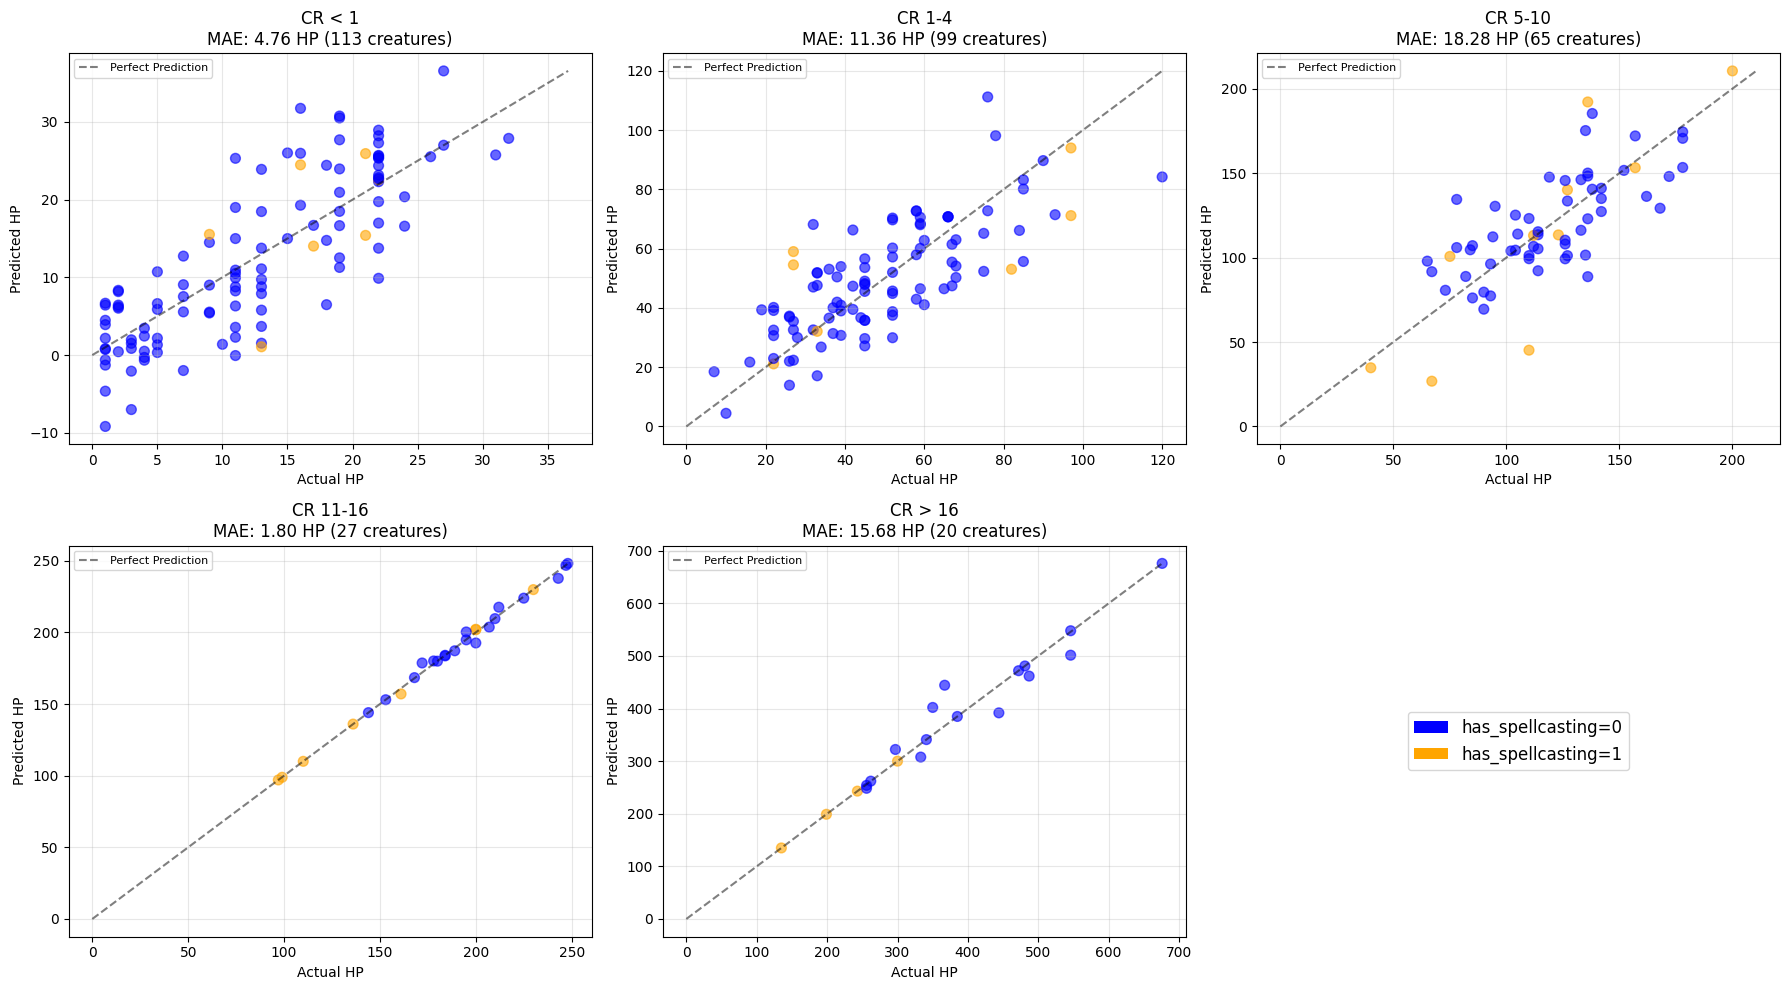

In [44]:
plot_performance_scatter(analysis_dfs, highlight_feature='has_spellcasting')

,Name,Type,Size,Challenge_Rating,cr_numeric,cr_tier,HP,hp_baseline,actual_hp,predicted_hp,...,inflicts_paralyzed,inflicts_petrified,inflicts_restrained,inflicts_stunned,Actual_HP,Predicted_HP,CR,Error,Abs_Error,Pct_Error
23,Unicorn,celestial,Large,5,5.0,cr3,67 (9d10+18),114.0,67,26.798148,...,0,0,1,0,67,26.798148,5.0,40.201852,40.201852,60.002765
29,Mage,humanoid (any race),Medium,6,6.0,cr3,40 (9d8),134.4,40,34.745440,...,0,0,0,0,40,34.745440,6.0,5.254560,5.254560,13.136401
38,Oni,giant,Large,7,7.0,cr3,110 (13d10+39),156.0,110,45.156698,...,0,0,0,0,110,45.156698,7.0,64.843302,64.843302,58.948457
8,Salamander,elemental,Large,5,5.0,cr3,90 (12d10+24),114.0,90,69.431730,...,0,0,1,0,90,69.431730,5.0,20.568270,20.568270,22.853633
49,Chain Devil,fiend (devil),Medium,8,8.0,cr3,85 (10d8+40),163.2,85,76.101610,...,0,0,1,0,85,76.101610,8.0,8.898390,8.898390,10.468694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,Young Gold Dragon,dragon,Large,10,10.0,cr3,178 (17d10+85),186.0,178,174.427952,...,0,0,0,0,178,174.427952,10.0,3.572048,3.572048,2.006768
64,Aboleth,aberration,Large,10,10.0,cr3,135 (18d10+36),186.0,135,175.201886,...,0,0,0,0,135,175.201886,10.0,-40.201886,40.201886,-29.779175
55,Treant,plant,Huge,9,9.0,cr3,138 (12d12+60),174.0,138,185.306887,...,0,0,0,0,138,185.306887,9.0,-47.306887,47.306887,-34.280353
60,Deva,celestial,Medium,10,10.0,cr3,136 (16d8+64),186.0,136,192.147553,...,0,0,0,0,136,192.147553,10.0,-56.147553,56.147553,-41.284965



📊 VISUALIZATION: Error Distribution (5 CR Buckets)


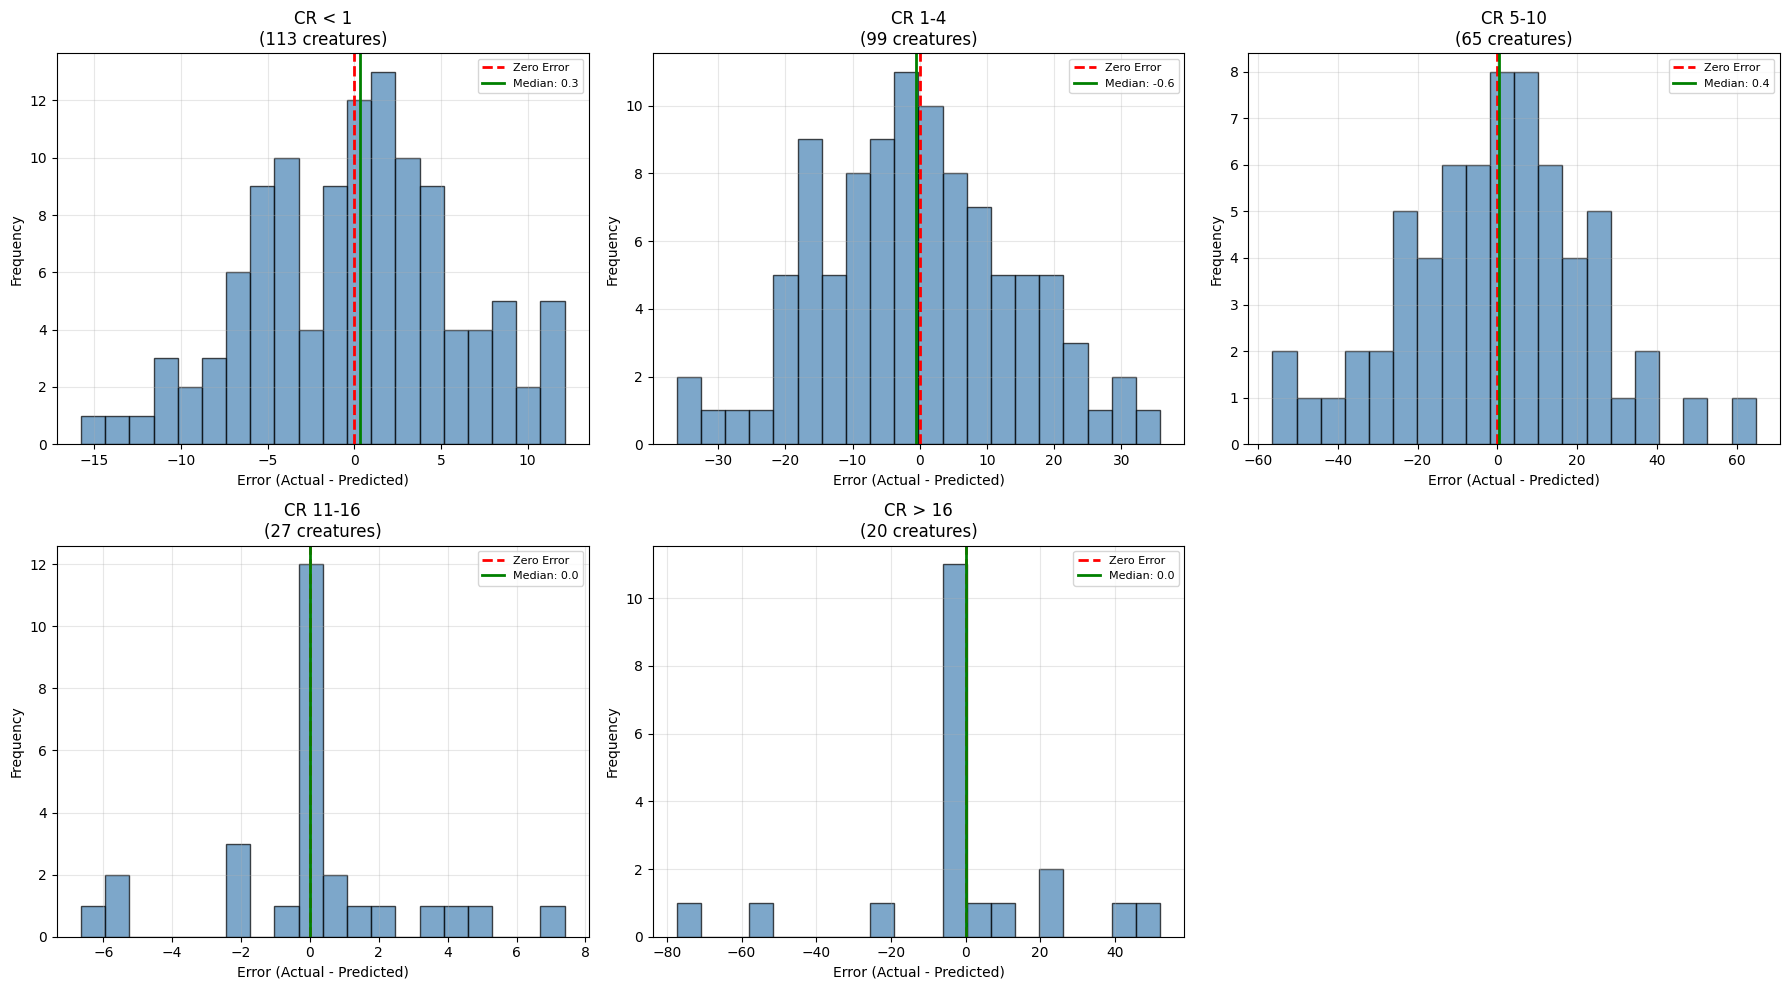

In [45]:
plot_error_hist(analysis_dfs)